In [4]:
# Step 1: Load the dataset
import pandas as pd

# Use raw string (r"...") or forward slashes to avoid unicodeescape errors
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# Inspect the dataset
print("Shape:", df.shape)                # rows and columns
print("Columns:", df.columns.tolist())   # list of column names
df.head()                                # preview first 5 rows

Shape: (400, 16)
Columns: ['user_id', 'age', 'gender', 'occupation', 'work_mode', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_per_week', 'social_hours_per_week', 'mental_wellness_index_0_100', 'Unnamed: 15']


,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN


In [5]:
# Step 2: Inspect data quality

# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Check data types of each column
print("\nData types:\n", df.dtypes)

# Quick descriptive statistics for numeric columns
print("\nSummary statistics:\n", df.describe())

Missing values per column:
 user_id                          0
age                              0
gender                           0
occupation                       0
work_mode                        0
screen_time_hours                0
work_screen_hours                0
leisure_screen_hours             0
sleep_hours                      0
sleep_quality_1_5                0
stress_level_0_10                0
productivity_0_100               0
exercise_minutes_per_week        0
social_hours_per_week            0
mental_wellness_index_0_100      0
Unnamed: 15                    400
dtype: int64

Number of duplicate rows: 0

Data types:
 user_id                            str
age                              int64
gender                             str
occupation                         str
work_mode                          str
screen_time_hours              float64
work_screen_hours              float64
leisure_screen_hours           float64
sleep_hours                    float64
sleep

In [6]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['gender', 'occupation', 'work_mode']
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print("Categorical encoding complete.")
df[categorical_cols].head()

Categorical encoding complete.


,gender,occupation,work_mode
0,0,0,2
1,0,0,1
2,0,0,0
3,1,0,0
4,1,3,2


In [7]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = [
    'screen_time_hours','work_screen_hours','leisure_screen_hours',
    'sleep_hours','sleep_quality_1_5','stress_level_0_10',
    'productivity_0_100','exercise_minutes_per_week',
    'social_hours_per_week','mental_wellness_index_0_100'
]

scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Scaling complete.")
df[cols_to_scale].head()

Scaling complete.


,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,0.538800,0.446773,0.357945,0.390196,0.000000,0.93,0.303526,0.341398,0.029289,0.095876
1,0.352229,0.021794,0.492777,0.668627,0.666667,0.57,0.722922,0.198925,0.087866,0.579381
2,0.483214,0.082146,0.626003,0.360784,0.000000,0.91,0.392947,0.180108,0.334728,0.037113
3,0.557512,0.037720,0.776886,0.441176,0.000000,1.00,0.206549,0.000000,0.238494,0.000000
4,0.672537,0.333613,0.661316,0.225490,0.000000,1.00,0.225441,0.384409,0.422594,0.000000


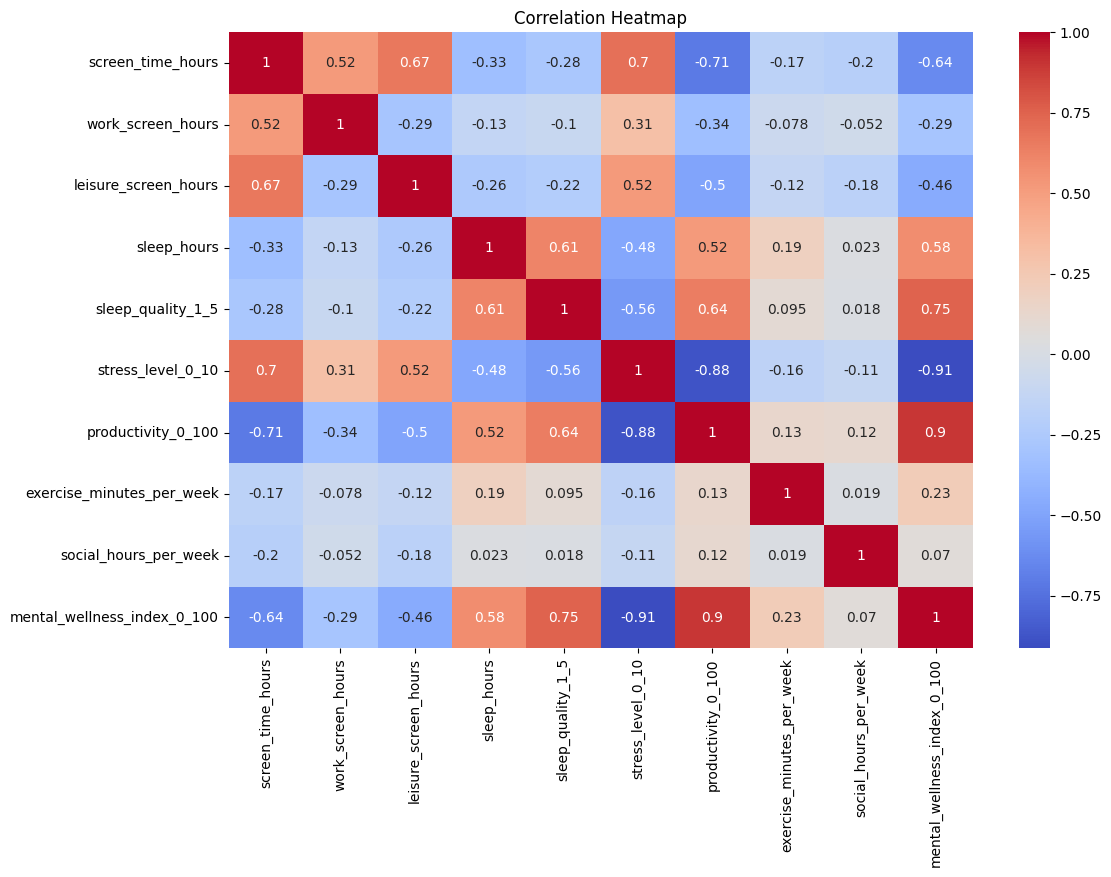

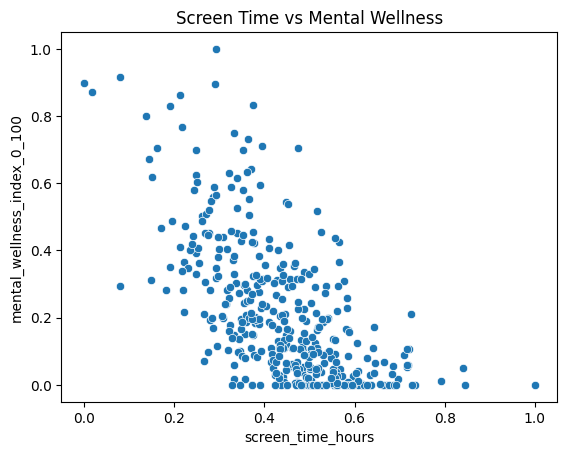

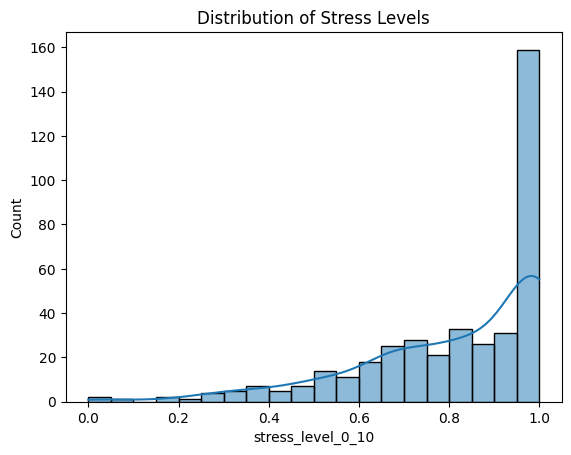

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df[cols_to_scale].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatterplot: Screen Time vs Mental Wellness
sns.scatterplot(x='screen_time_hours', y='mental_wellness_index_0_100', data=df)
plt.title("Screen Time vs Mental Wellness")
plt.show()

# Distribution of Stress Levels
sns.histplot(df['stress_level_0_10'], bins=20, kde=True)
plt.title("Distribution of Stress Levels")
plt.show()

Clustering complete.


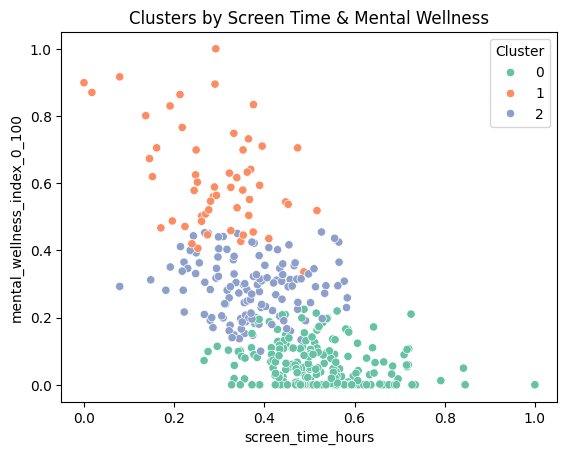

         screen_time_hours  work_screen_hours  leisure_screen_hours  \
Cluster                                                               
0                 0.519999           0.212777              0.554571   
1                 0.291099           0.100053              0.328703   
2                 0.373534           0.139315              0.411322   

         sleep_hours  sleep_quality_1_5  stress_level_0_10  \
Cluster                                                      
0           0.382769           0.023041           0.955530   
1           0.658360           0.478788           0.434364   
2           0.522350           0.169271           0.740469   

         productivity_0_100  exercise_minutes_per_week  social_hours_per_week  \
Cluster                                                                         
0                  0.296689                   0.254001               0.320132   
1                  0.762698                   0.352590               0.410270   
2        

In [9]:
from sklearn.cluster import KMeans

X = df[cols_to_scale]
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

print("Clustering complete.")
sns.scatterplot(x='screen_time_hours', y='mental_wellness_index_0_100', hue='Cluster', data=df, palette='Set2')
plt.title("Clusters by Screen Time & Mental Wellness")
plt.show()

# Cluster summary
print(df.groupby('Cluster')[cols_to_scale].mean())

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Predict mental wellness index
X = df.drop(columns=['mental_wellness_index_0_100','Cluster','user_id'])
y = df['mental_wellness_index_0_100']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# Feature importance
import pandas as pd
importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance for Mental Wellness Prediction")
plt.show()

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [11]:
# Drop user_id and any other non-numeric columns
X = df.drop(columns=['user_id', 'mental_wellness_index_0_100', 'Cluster'])
y = df['mental_wellness_index_0_100']

In [12]:
print("Missing in X:", X.isnull().sum().sum())
print("Missing in y:", y.isnull().sum())

Missing in X: 400
Missing in y: 0


In [13]:
X = X.dropna()
y = y.loc[X.index]  # align y with cleaned X

In [14]:
print("X types:\n", X.dtypes)
print("y type:", y.dtype)

X types:
 age                            int64
gender                         int64
occupation                     int64
work_mode                      int64
screen_time_hours            float64
work_screen_hours            float64
leisure_screen_hours         float64
sleep_hours                  float64
sleep_quality_1_5            float64
stress_level_0_10            float64
productivity_0_100           float64
exercise_minutes_per_week    float64
social_hours_per_week        float64
Unnamed: 15                  float64
dtype: object
y type: float64


In [15]:
X = X.apply(pd.to_numeric, errors='coerce')

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [17]:
# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
from sklearn.metrics import mean_squared_error, r2_score

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [18]:
# Drop the unnamed column if it exists
if 'Unnamed: 15' in X.columns:
    X = X.drop(columns=['Unnamed: 15'])

In [19]:
print("Missing in X:", X.isnull().sum().sum())
print("Missing in y:", y.isnull().sum())

Missing in X: 0
Missing in y: 0


In [20]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (320, 14)
y_train shape: (320,)


In [21]:
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in y_train:", y_train.isnull().sum())
print("Infinite in X_train:", np.isinf(X_train).sum().sum())
print("Infinite in y_train:", np.isinf(y_train).sum())

NaNs in X_train: 320
NaNs in y_train: 0


NameError: name 'np' is not defined

In [22]:
import numpy as np

In [23]:
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in y_train:", y_train.isnull().sum())
print("Infinite in X_train:", np.isinf(X_train).sum().sum())
print("Infinite in y_train:", np.isinf(y_train).sum())

NaNs in X_train: 320
NaNs in y_train: 0
Infinite in X_train: 0
Infinite in y_train: 0


In [24]:
X_train_clean = X_train.dropna()
y_train_clean = y_train.loc[X_train_clean.index]  # realign y

In [25]:
model.fit(X_train_clean, y_train_clean)
y_pred = model.predict(X_test.dropna())  # optional: clean X_test too

from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test.loc[X_test.dropna().index], y_pred))
print("R²:", r2_score(y_test.loc[X_test.dropna().index], y_pred))

ValueError: Found array with 0 sample(s) (shape=(0, 14)) while a minimum of 1 is required by LinearRegression.

In [27]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# Drop junk columns like 'Unnamed: 15' or any unnamed extras
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Drop rows with any missing values
df = df.dropna()

# Encode categorical columns
categorical_cols = ['gender', 'occupation', 'work_mode']
for col in categorical_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col])

# Scale numeric columns
numeric_cols = [
    'screen_time_hours','work_screen_hours','leisure_screen_hours',
    'sleep_hours','sleep_quality_1_5','stress_level_0_10',
    'productivity_0_100','exercise_minutes_per_week',
    'social_hours_per_week','mental_wellness_index_0_100'
]
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Final cleanup: drop any remaining NaNs
df = df.dropna()

# Define features and target
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# Feature importance visualization
importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(10,6), color='teal')
plt.title("Feature Importance for Mental Wellness Prediction")
plt.xlabel("Coefficient Value")
plt.grid(True)
plt.show()

ValueError: could not convert string to float: 'U0004'

In [28]:
print("Original shape:", df.shape)
print("After dropna:", df.dropna().shape)

Original shape: (400, 15)
After dropna: (400, 15)


In [29]:
# Fill numeric NaNs with column mean
df = df.fillna(df.mean(numeric_only=True))

# Fill categorical NaNs with mode
for col in ['gender','occupation','work_mode']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

In [30]:
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (400, 14)
Final y shape: (400,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

ValueError: could not convert string to float: 'U0004'

In [32]:
# Fill numeric NaNs with column mean
df = df.fillna(df.mean(numeric_only=True))

# Fill categorical NaNs with mode
for col in ['gender','occupation','work_mode']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

In [33]:
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (400, 14)
Final y shape: (400,)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)   # should now work

ValueError: could not convert string to float: 'U0004'

In [1]:
# Find non-numeric columns
non_numeric = X.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric)

# Inspect unique values in those columns
for col in non_numeric:
    print(f"\nColumn: {col}")
    print(X[col].unique()[:20])  # show first 20 unique values

NameError: name 'X' is not defined

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# Drop junk columns like Unnamed
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (400, 15)
Columns: ['user_id', 'age', 'gender', 'occupation', 'work_mode', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_per_week', 'social_hours_per_week', 'mental_wellness_index_0_100']


In [3]:
Shape: (400, 15)
Columns: ['user_id', 'age', 'gender', 'occupation', 'work_mode', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_per_week', 'social_hours_per_week', 'mental_wellness_index_0_100']

In [4]:
from sklearn.preprocessing import LabelEncoder

for col in ['gender','occupation','work_mode']:
    df[col] = LabelEncoder().fit_transform(df[col])

In [5]:
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

ValueError: could not convert string to float: 'U0004'

In [7]:
non_numeric = X.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric)

for col in non_numeric:
    print(f"\nColumn: {col}")
    print(X[col].unique()[:20])  # show first 20 unique values

Non-numeric columns: Index(['user_id'], dtype='str')

Column: user_id
<StringArray>
['U0001', 'U0002', 'U0003', 'U0004', 'U0005', 'U0006', 'U0007', 'U0008',
 'U0009', 'U0010', 'U0011', 'U0012', 'U0013', 'U0014', 'U0015', 'U0016',
 'U0017', 'U0018', 'U0019', 'U0020']
Length: 20, dtype: str


C:\Users\b7019\AppData\Local\Temp\ipykernel_19672\4261831818.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  non_numeric = X.select_dtypes(include=['object']).columns


In [8]:
X = df.drop(columns=['mental_wellness_index_0_100', 'user_id'])
y = df['mental_wellness_index_0_100']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target, dropping user_id
X = df.drop(columns=['mental_wellness_index_0_100', 'user_id'])
y = df['mental_wellness_index_0_100']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 27.69959423944431
R²: 0.9299670322589764


In [10]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (320, 13)
y_train shape: (320,)


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 27.69959423944431
R² Score: 0.9299670322589764


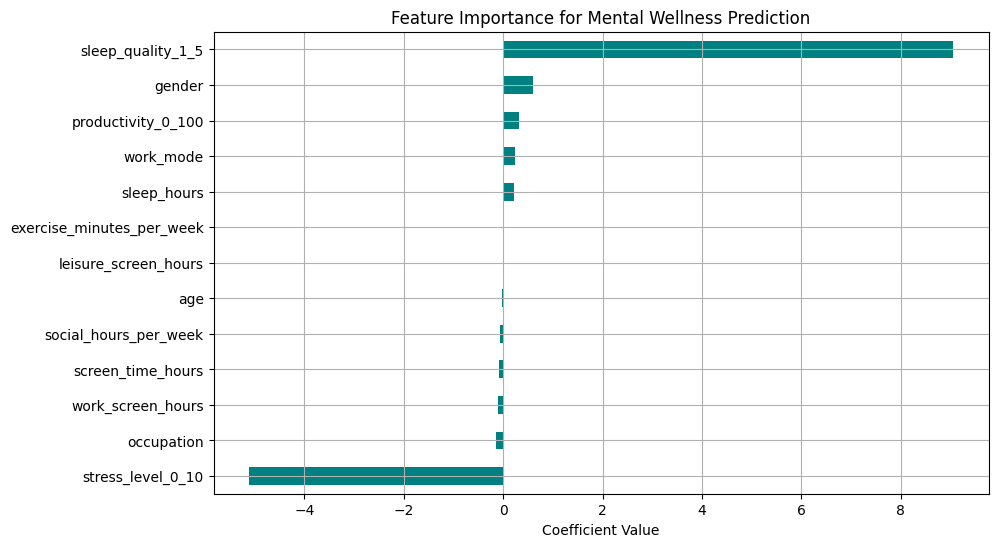

In [12]:
import matplotlib.pyplot as plt
importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(10,6), color='teal')
plt.title("Feature Importance for Mental Wellness Prediction")
plt.xlabel("Coefficient Value")
plt.grid(True)
plt.show()

In [1]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Average R²:", scores.mean())

NameError: name 'model' is not defined

In [2]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Define features and target again if needed
X = df.drop(columns=['mental_wellness_index_0_100', 'user_id'])
y = df['mental_wellness_index_0_100']

# Create the model
model = LinearRegression()

# Run cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Average R²:", scores.mean())

NameError: name 'df' is not defined

In [3]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# 1. Load your dataset again
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# 2. Drop irrelevant columns
df = df.drop(columns=['user_id'])

# 3. Define features and target
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

# 4. Create the model
model = LinearRegression()

# 5. Cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Average R²:", scores.mean())

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_base.py", line 630, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        force_writeable=True,
 

In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# 1. Load dataset
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# 2. Drop irrelevant columns
if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

# 3. Define features and target
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

# 4. Create the model
model = LinearRegression()

# 5. Cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Average R²:", scores.mean())

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_base.py", line 630, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        force_writeable=True,
 

In [5]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# 1. Load dataset
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# 2. Drop irrelevant columns
if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

# 3. Handle missing values
# Fill numeric NaNs with column mean
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical NaNs with mode
for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. Define features and target
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

# 5. Create the model
model = LinearRegression()

# 6. Cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Average R²:", scores.mean())

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_base.py", line 630, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        force_writeable=True,
 

In [6]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1. Load dataset
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# 2. Drop irrelevant columns
if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

# 3. Define features and target
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

# 4. Build pipeline with imputer + model
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # replaces NaNs with column mean
    ('model', LinearRegression())
])

# 5. Cross-validation
scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Average R²:", scores.mean())

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
  File "C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\pipe

In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1. Load dataset
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# 2. Drop irrelevant columns
if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

# 3. Define features and target
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

# 4. Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 5. Preprocessing for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Build pipeline with preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 7. Cross-validation
scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Average R²:", scores.mean())

C:\Users\b7019\AppData\Local\Temp\ipykernel_30768\2442375717.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()
C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Unnamed: 15']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features with

Cross-validated R² scores: [0.94987244 0.94529686 0.87202973 0.92030587 0.93480665]
Average R²: 0.924462308975096


In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1. Load dataset
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# 2. Drop irrelevant columns
if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

# 3. Define features and target
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

# 4. Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 5. Preprocessing for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Build pipeline with preprocessing + Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

# 7. Cross-validation
scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores (Random Forest):", scores)
print("Average R² (Random Forest):", scores.mean())

C:\Users\b7019\AppData\Local\Temp\ipykernel_18824\1085599734.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()
C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Unnamed: 15']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features with

Cross-validated R² scores (Random Forest): [0.92841924 0.89100726 0.86690852 0.89236087 0.90915612]
Average R² (Random Forest): 0.8975704009394476


C:\Users\b7019\AppData\Roaming\Python\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Unnamed: 15']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1. Load dataset
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# 2. Drop irrelevant and empty columns
if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])
df = df.dropna(axis=1, how='all')   # removes completely empty columns like 'Unnamed: 15'

# 3. Define features and target
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

# 4. Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 5. Preprocessing for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Build pipeline with preprocessing + Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

# 7. Cross-validation
scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores (Random Forest):", scores)
print("Average R² (Random Forest):", scores.mean())

C:\Users\b7019\AppData\Local\Temp\ipykernel_18824\1663502731.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


Cross-validated R² scores (Random Forest): [0.92841924 0.89100726 0.86690852 0.89236087 0.90915612]
Average R² (Random Forest): 0.8975704009394476


In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1. Load dataset
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# 2. Drop irrelevant and empty columns
if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])
df = df.dropna(axis=1, how='all')   # removes completely empty columns like 'Unnamed: 15'

# 3. Define features and target
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

# 4. Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','string']).columns.tolist()  # updated to avoid warning

# 5. Preprocessing for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Build pipeline with preprocessing + Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

# 7. Cross-validation
scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores (Random Forest):", scores)
print("Average R² (Random Forest):", scores.mean())

Cross-validated R² scores (Random Forest): [0.92841924 0.89100726 0.86690852 0.89236087 0.90915612]
Average R² (Random Forest): 0.8975704009394476


In [4]:
import pandas as pd

# Example single input row (make sure the column names match your dataset exactly)
sample_input = pd.DataFrame([{
    'sleep_quality_1_5': 4,
    'gender': 'Female',
    'productivity_0_100': 75,
    'work_mode': 'Hybrid',
    'sleep_hours': 7,
    'exercise_minutes_per_week': 150,
    'leisure_screen_hours': 3,
    'age': 22,
    'social_hours_per_week': 5,
    'screen_time_hours': 6,
    'work_screen_hours': 5,
    'occupation': 'Student',
    'stress_level_0_10': 4
}])

# Predict mental wellness score
predicted_score = rf_pipeline.predict(sample_input)
print("Predicted Mental Wellness Index:", predicted_score[0])

NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1. Load dataset
df = pd.read_csv(r"C:\Users\b7019\OneDrive\Desktop\final yr project\dataset\ScreenTime vs MentalWellness.csv")

# 2. Drop irrelevant and empty columns
if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])
df = df.dropna(axis=1, how='all')   # removes completely empty columns like 'Unnamed: 15'

# 3. Define features and target
X = df.drop(columns=['mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

# 4. Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','string']).columns.tolist()

# 5. Preprocessing for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Build pipeline with preprocessing + Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

# 7. Fit the pipeline on the full dataset
rf_pipeline.fit(X, y)

# 8. Test with a custom input row
sample_input = pd.DataFrame([{
    'sleep_quality_1_5': 4,
    'gender': 'Female',
    'productivity_0_100': 75,
    'work_mode': 'Hybrid',
    'sleep_hours': 7,
    'exercise_minutes_per_week': 150,
    'leisure_screen_hours': 3,
    'age': 22,
    'social_hours_per_week': 5,
    'screen_time_hours': 6,
    'work_screen_hours': 5,
    'occupation': 'Student',
    'stress_level_0_10': 4
}])

predicted_score = rf_pipeline.predict(sample_input)
print("Predicted Mental Wellness Index:", predicted_score[0])

Predicted Mental Wellness Index: 55.025000000000034


In [6]:
sample_input1 = pd.DataFrame([{
    'sleep_quality_1_5': 2,
    'gender': 'Male',
    'productivity_0_100': 40,
    'work_mode': 'Remote',
    'sleep_hours': 5,
    'exercise_minutes_per_week': 30,
    'leisure_screen_hours': 6,
    'age': 25,
    'social_hours_per_week': 2,
    'screen_time_hours': 9,
    'work_screen_hours': 7,
    'occupation': 'Engineer',
    'stress_level_0_10': 8
}])

print("Scenario 1 Prediction:", rf_pipeline.predict(sample_input1)[0])

Scenario 1 Prediction: 18.072000000000006


In [7]:
sample_input2 = pd.DataFrame([{
    'sleep_quality_1_5': 5,
    'gender': 'Female',
    'productivity_0_100': 85,
    'work_mode': 'Onsite',
    'sleep_hours': 8,
    'exercise_minutes_per_week': 200,
    'leisure_screen_hours': 2,
    'age': 28,
    'social_hours_per_week': 8,
    'screen_time_hours': 4,
    'work_screen_hours': 3,
    'occupation': 'Designer',
    'stress_level_0_10': 2
}])

print("Scenario 2 Prediction:", rf_pipeline.predict(sample_input2)[0])

Scenario 2 Prediction: 68.10249999999998


In [8]:
sample_input_high2 = pd.DataFrame([{
    'sleep_quality_1_5': 5,           # excellent sleep quality
    'gender': 'Male',
    'productivity_0_100': 88,         # high productivity
    'work_mode': 'Hybrid',
    'sleep_hours': 8,                 # full sleep
    'exercise_minutes_per_week': 180, # regular exercise
    'leisure_screen_hours': 2,
    'age': 24,
    'social_hours_per_week': 9,       # strong social life
    'screen_time_hours': 5,
    'work_screen_hours': 4,
    'occupation': 'Student',
    'stress_level_0_10': 2            # very low stress
}])

predicted_score_high2 = rf_pipeline.predict(sample_input_high2)
print("High Wellness Scenario 2 Prediction:", predicted_score_high2[0])

High Wellness Scenario 2 Prediction: 72.59249999999999
